In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mksaad/arabic-sentiment-twitter-corpus")

print("Path to dataset files:", path)

C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\hp\.cache\kagglehub\datasets\mksaad\arabic-sentiment-twitter-corpus\versions\2


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
!pip install emoji -q


[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
train_pos = pd.read_csv(path + "/train_Arabic_tweets_positive_20190413.tsv", sep='\t', header=None)
train_neg = pd.read_csv(path + "/train_Arabic_tweets_negative_20190413.tsv", sep='\t', header=None)
test_pos = pd.read_csv(path + "/test_Arabic_tweets_positive_20190413.tsv", sep='\t', header=None)
test_neg = pd.read_csv(path + "/test_Arabic_tweets_negative_20190413.tsv", sep='\t', header=None)

In [5]:
train_pos.head()

,0,1
0,pos,نحن الذين يتحول كل ما نود أن نقوله إلى دعاء لل...
1,pos,وفي النهاية لن يبقىٰ معك آحدإلا من رأىٰ الجمال...
2,pos,من الخير نفسه 💛
3,pos,#زلزل_الملعب_نصرنا_بيلعب كن عالي الهمه ولا ترض...
4,pos,الشيء الوحيد الذي وصلوا فيه للعالمية هو : المس...


In [6]:
train_neg.head()

,0,1
0,neg,اعترف ان بتس كانو شوي شوي يجيبو راسي لكن اليوم...
1,neg,توقعت اذا جات داريا بشوفهم كاملين بس لي للحين ...
2,neg,#الاهلي_الهلال اكتب توقعك لنتيجة لقاء الهلال و...
3,neg,نعمة المضادات الحيوية . تضع قطرة💧مضاد بنسلين ع...
4,neg,الدودو جايه تكمل علي 💔


In [7]:
train_pos = train_pos.rename(columns={0: "Sentiment", 1: "comment"})
train_neg = train_neg.rename(columns={0: "Sentiment", 1: "comment"})
test_pos = test_pos.rename(columns={0: "Sentiment", 1: "comment"})
test_neg = test_neg.rename(columns={0: "Sentiment", 1: "comment"})

In [8]:
train_data = pd.concat([train_pos, train_neg])
test_data = pd.concat([test_pos, test_neg])

In [9]:
train_data

,Sentiment,comment
0,pos,نحن الذين يتحول كل ما نود أن نقوله إلى دعاء لل...
1,pos,وفي النهاية لن يبقىٰ معك آحدإلا من رأىٰ الجمال...
2,pos,من الخير نفسه 💛
3,pos,#زلزل_الملعب_نصرنا_بيلعب كن عالي الهمه ولا ترض...
4,pos,الشيء الوحيد الذي وصلوا فيه للعالمية هو : المس...
...,...,...
22509,neg,كيف ترى أورانوس لو كان يقع مكان القمر ؟ 💙💙 كوك...
22510,neg,احسدك على الايم 💔
22511,neg,لأول مرة ما بنكون سوا 💔
22512,neg,بقله ليش يا واطي 🤔


In [10]:
#random the data
train_data = train_data.sample(frac=1).reset_index(drop=True)
test_data = test_data.sample(frac=1).reset_index(drop=True)

In [11]:
train_data

,Sentiment,comment
0,pos,شهور تستاهل الزرقاء
1,neg,طلال مداح 😢
2,neg,ليتك تفرحنا وتحكيلنا قصة ليمان وكيف كان يأمر ا...
3,pos,من تعنى لوصلك لاترده كسير ومن تباهى بهجرك اترك...
4,pos,💎 الحمدلله الذي اختارلنا محاسن الخلق وأجرى علي...
...,...,...
45270,pos,و بيبدا الثرونز بعد كم يوم 😂
45271,pos,الف مبروك والفال لك يالغالي 💙
45272,neg,يا عبد الرحمن ما كان تكتب كده حسستني انو الاعت...
45273,neg,هذي القاعده حقتي معليش 🌚


In [32]:
train_data.shape

(45275, 2)

In [33]:
test_data.shape

(11520, 2)

In [34]:
train_data['Sentiment'].value_counts()

Sentiment
pos    22761
neg    22514
Name: count, dtype: int64

In [35]:
def normalize_arabic(text):
  # Remove diacritics
    text = re.sub(r'[\u064B-\u065F\u0670]', '', text)
  # Normalize letters variations
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ؤ", "ء", text)
    text = re.sub("ئ", "ء", text)
    text = re.sub("ة", "ه", text)
    text = re.sub("گ", "ك", text)
    text = re.sub("ڤ", "ف", text)
    text = re.sub("چ", "ج", text)
    text = re.sub("پ", "ب", text)
    text = re.sub("ڜ", "ش", text)
    text = re.sub("ڪ", "ك", text)
    text = re.sub("ڧ", "ق", text)
    text = re.sub("ٱ", "ا", text)
    return text

In [36]:
train_data['comment'] = train_data['comment'].apply(normalize_arabic)
test_data['comment'] = test_data['comment'].apply(normalize_arabic)

In [37]:
import emoji

def handle_emojis(text, mode='remove'):
    if mode == 'remove':
        return emoji.replace_emoji(text, '')
    elif mode == 'description':
        return emoji.demojize(text, language='ar')
    return text

In [38]:
train_data['comment'] = train_data['comment'].apply(lambda x: handle_emojis(x, mode='description'))
test_data['comment'] = test_data['comment'].apply(lambda x: handle_emojis(x, mode='description'))

In [39]:
def remove_arabic_noise(text):
    # Remove tatweel
    text = re.sub(r'\u0640', '', text)
    # Remove HTML tags
    text = re.sub('<.*?>', '', text)
    # Remove extra whitespaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [40]:
train_data['comment'] = train_data['comment'].apply(remove_arabic_noise)
test_data['comment'] = test_data['comment'].apply(remove_arabic_noise)

In [41]:
train_data

,Sentiment,comment
0,pos,حبيبي والله :قلب_أزرق:
1,pos,":وردة: ""اللهم ارزقنا رضاء النفس وزكاه الروح وز..."
2,neg,#وش_تعلمت_من_الدنياء ان صاحب الهاشتاق بليد في ...
3,neg,اي فكره لفرض رسوم علي التجار مرفووضه بعذر انهم...
4,neg,انا بشوف شغلات ع تويتر مستحيل اشوفها بمكان تاني
...,...,...
45270,neg,بوي وذ لوف وصلت مليون :وجه_يبكي_بكاء_مرتفعا:
45271,neg,عيطت لما عنيا ورمت :وجه_ضفدع:
45272,pos,#مباراه_منقوله_غدا :كاميرا_أفلام: البكيريه :عل...
45273,neg,مع بدء العد التنازلي ل #رمضان، يجب ان نتفطن لل...


In [42]:
#remove puncatuations
arabic_punctuations = '''`÷×؛<>_()*&^%][ـ،/:"؟.,'{}~¦+|!”…“–ـ'''
english_punctuations = r"""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""

all_punctuations = arabic_punctuations + english_punctuations

def remove_arabic_punctuations(text):
    return re.sub(f"[{re.escape(all_punctuations)}]", " ", text)

In [43]:
train_data['comment'] = train_data['comment'].apply(remove_arabic_punctuations)
test_data['comment'] = test_data['comment'].apply(remove_arabic_punctuations)

In [44]:
train_data

,Sentiment,comment
0,pos,حبيبي والله قلب أزرق
1,pos,وردة اللهم ارزقنا رضاء النفس وزكاه الروح وز...
2,neg,وش تعلمت من الدنياء ان صاحب الهاشتاق بليد في ...
3,neg,اي فكره لفرض رسوم علي التجار مرفووضه بعذر انهم...
4,neg,انا بشوف شغلات ع تويتر مستحيل اشوفها بمكان تاني
...,...,...
45270,neg,بوي وذ لوف وصلت مليون وجه يبكي بكاء مرتفعا
45271,neg,عيطت لما عنيا ورمت وجه ضفدع
45272,pos,مباراه منقوله غدا كاميرا أفلام البكيريه عل...
45273,neg,مع بدء العد التنازلي ل رمضان يجب ان نتفطن لل...


In [45]:
def correct_arabic_text(text):
    corrections = {
        'انشاء الله': 'إن شاء الله',
        'لاكن': 'لكن',
        'انشالله': 'إن شاء الله',
        'هاذا': 'هذا',
    }

    for mistake, correction in corrections.items():
        text = text.replace(mistake, correction)

    return text

In [46]:
train_data['comment'] = train_data['comment'].apply(correct_arabic_text)
test_data['comment'] = test_data['comment'].apply(correct_arabic_text)

In [47]:
def handle_numbers_and_special_chars(text, mode='remove'):
    if mode == 'remove':
        text = re.sub(r'\d+', '', text)
        return text
    elif mode == 'normalize':
        number_map = {
                      '٠': 'صفر',
                      '١': 'واحد',
                      '٢': 'اثنان',
                      '٣': 'ثلاثة',
                      '٤': 'أربعة',
                      '٥': 'خمسة',
                      '٦': 'ستة',
                      '٧': 'سبعة',
                      '٨': 'ثمانية',
                      '٩': 'تسعة',
                      '0': 'صفر',
                      '1': 'واحد',
                      '2': 'اثنان',
                      '3': 'ثلاثة',
                      '4': 'أربعة',
                      '5': 'خمسة',
                      '6': 'ستة',
                      '7': 'سبعة',
                      '8': 'ثمانية',
                      '9': 'تسعة'
                  }
        for arabic, name in number_map.items():
            text = text.replace(arabic, name)
        return text

In [48]:
train_data['comment'] = train_data['comment'].apply(lambda x: handle_numbers_and_special_chars(x, mode='normalize'))
test_data['comment'] = test_data['comment'].apply(lambda x: handle_numbers_and_special_chars(x, mode='normalize'))

In [49]:
def arabizi_to_arabic(text):
    # This is a simplified conversion. A complete solution would be more complex.
    conversion_dict = {
        'a': 'ا', 'b': 'ب', 't': 'ت', 'th': 'ث', 'g': 'ج', '7': 'ح', 'kh': 'خ',
        'd': 'د', 'th': 'ذ', 'r': 'ر', 'z': 'ز', 's': 'س', 'sh': 'ش', '9': 'ص',
        '6': 'ط', '3': 'ع', 'gh': 'غ', 'f': 'ف', 'q': 'ق', 'k': 'ك', 'l': 'ل',
        'm': 'م', 'n': 'ن', 'h': 'ه', 'w': 'و', 'y': 'ي'
    }

    for latin, arabic in conversion_dict.items():
        text = text.replace(latin, arabic)

    return text

In [50]:
train_data['comment'] = train_data['comment'].apply(arabizi_to_arabic)
test_data['comment'] = test_data['comment'].apply(arabizi_to_arabic)

In [51]:
def normalize_elongated_words(text):
    # Remove elongation
    text = re.sub(r'(.)\1+', r'\1\1', text)
    return text

In [52]:
train_data['comment'] = train_data['comment'].apply(normalize_elongated_words)
test_data['comment'] = test_data['comment'].apply(normalize_elongated_words)

In [53]:
!pip -q install nltk
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('punkt_tab')


[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [54]:
train_data['comment'] = train_data['comment'].apply(lambda x: word_tokenize(x))
test_data['comment'] = test_data['comment'].apply(lambda x: word_tokenize(x))

In [55]:
train_data

,Sentiment,comment
0,pos,"[حبيبي, والله, قلب, أزرق]"
1,pos,"[وردة, اللهم, ارزقنا, رضاء, النفس, وزكاه, الرو..."
2,neg,"[وش, تعلمت, من, الدنياء, ان, صاحب, الهاشتاق, ب..."
3,neg,"[اي, فكره, لفرض, رسوم, علي, التجار, مرفووضه, ب..."
4,neg,"[انا, بشوف, شغلات, ع, تويتر, مستحيل, اشوفها, ب..."
...,...,...
45270,neg,"[بوي, وذ, لوف, وصلت, مليون, وجه, يبكي, بكاء, م..."
45271,neg,"[عيطت, لما, عنيا, ورمت, وجه, ضفدع]"
45272,pos,"[مباراه, منقوله, غدا, كاميرا, أفلام, البكيريه,..."
45273,neg,"[مع, بدء, العد, التنازلي, ل, رمضان, يجب, ان, ن..."


In [56]:
arabic_stopwords = set(stopwords.words('arabic'))
train_data['comment'] = train_data['comment'].apply(lambda x: [word for word in x if word not in arabic_stopwords])
test_data['comment'] = test_data['comment'].apply(lambda x: [word for word in x if word not in arabic_stopwords])

In [57]:
train_data

,Sentiment,comment
0,pos,"[حبيبي, والله, قلب, أزرق]"
1,pos,"[وردة, اللهم, ارزقنا, رضاء, النفس, وزكاه, الرو..."
2,neg,"[وش, تعلمت, الدنياء, ان, صاحب, الهاشتاق, بليد,..."
3,neg,"[اي, فكره, لفرض, رسوم, علي, التجار, مرفووضه, ب..."
4,neg,"[انا, بشوف, شغلات, تويتر, مستحيل, اشوفها, بمكا..."
...,...,...
45270,neg,"[بوي, وذ, لوف, وصلت, مليون, وجه, يبكي, بكاء, م..."
45271,neg,"[عيطت, عنيا, ورمت, وجه, ضفدع]"
45272,pos,"[مباراه, منقوله, كاميرا, أفلام, البكيريه, علام..."
45273,neg,"[بدء, العد, التنازلي, رمضان, يجب, ان, نتفطن, ل..."


In [58]:
from nltk.stem.isri import ISRIStemmer
stemmer = ISRIStemmer()

In [59]:
train_data['comment'] = train_data['comment'].apply(lambda x: [stemmer.stem(word) for word in x])
test_data['comment'] = test_data['comment'].apply(lambda x: [stemmer.stem(word) for word in x])

In [60]:
train_data['Sentiment'] = train_data['Sentiment'].astype(str)
test_data['Sentiment'] = test_data['Sentiment'].astype(str)

from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
encoder.fit(pd.concat([train_data['Sentiment'], test_data['Sentiment']]).unique())

train_data['Sentiment'] = encoder.transform(train_data['Sentiment'])
test_data['Sentiment'] = encoder.transform(test_data['Sentiment'])

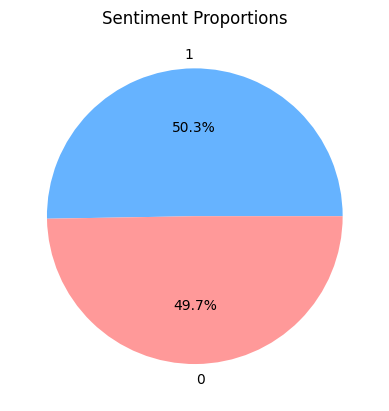

In [61]:
train_data['Sentiment'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#66b3ff','#ff9999','#99ff99'])
plt.title("Sentiment Proportions")
plt.ylabel("")  # hide y-label
plt.show()

In [62]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [63]:
train_data['comment'] = train_data['comment'].apply(lambda x: ' '.join(x))
test_data['comment'] = test_data['comment'].apply(lambda x: ' '.join(x))

vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(train_data['comment']) 
X_test = vectorizer.transform(test_data['comment'])
y_train = train_data['Sentiment']
y_test = test_data['Sentiment']

# Logistic Regresiion

In [64]:
model = LogisticRegression(C=1.5, max_iter=2000)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Train Accuracy: {train_accuracy}")
print(classification_report(y_train, y_train_pred))

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))

Train Accuracy: 0.9296963003865267
              precision    recall  f1-score   support

           0       0.94      0.92      0.93     22514
           1       0.92      0.94      0.93     22761

    accuracy                           0.93     45275
   macro avg       0.93      0.93      0.93     45275
weighted avg       0.93      0.93      0.93     45275

Accuracy: 0.9137152777777777
              precision    recall  f1-score   support

           0       0.93      0.90      0.91      5768
           1       0.90      0.93      0.91      5752

    accuracy                           0.91     11520
   macro avg       0.91      0.91      0.91     11520
weighted avg       0.91      0.91      0.91     11520



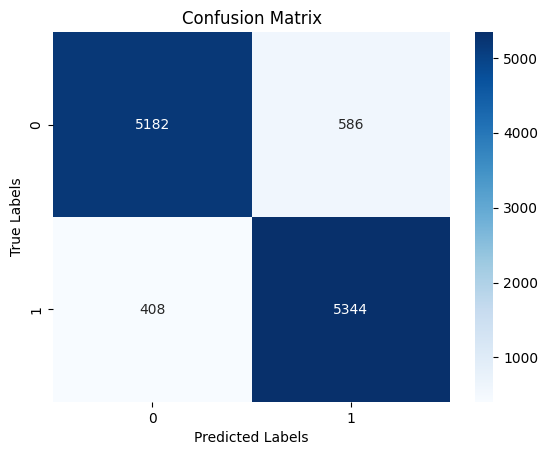

In [65]:
#display confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


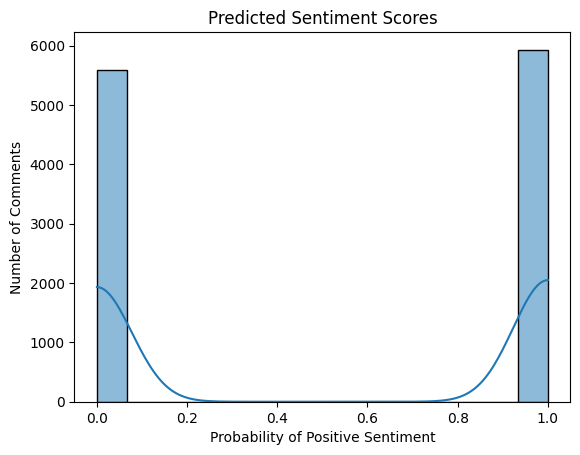

In [66]:
y_probs = model.predict(X_test).flatten()
sns.histplot(y_probs, bins=15, kde=True)
plt.title("Predicted Sentiment Scores")
plt.xlabel("Probability of Positive Sentiment")
plt.ylabel("Number of Comments")
plt.show()

In [67]:
from pathlib import Path
import joblib

BASE_DIR = Path().resolve().parent

models_dir = BASE_DIR / "models"
models_dir.mkdir(exist_ok=True)

joblib.dump(model, models_dir / "sentiment_model.pkl")
joblib.dump(vectorizer, models_dir / "tfidf_vectorizer.pkl")

['D:\\py\\Arabic Sentiment analysis\\arabic-sentiment-analyzer\\models\\tfidf_vectorizer.pkl']

In [68]:
#take subset of 100 comment from the test_data
test_subset = test_data.sample(n=100, random_state=42)
test_subset.to_csv("test_subset.csv", index=False)

In [12]:
#take subset of 100 comment only from the test_data
test_subset = test_data['comment'].sample(n=100, random_state=42)
test_subset.to_csv("test_subset.csv", index=False)